# Exploratory Data Analysis — I-94 Traffic Volume

**Objective:** Understand the structure, quality, distribution, and relationships within the traffic dataset, and derive concrete implications for building a traffic-volume forecasting model.

**Target variable:** `traffic_volume`

This notebook performs a purpose-driven EDA — every chart is built to answer a specific question about the data, followed by a short interpretation of what it shows.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

# Display / plotting configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11

PALETTE = sns.color_palette('viridis', as_cmap=False)
sns.set_palette('viridis')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
df = pd.read_csv('traffic_volume_cleaned.csv')
print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

Dataset loaded: 40,564 rows x 15 columns


## 1. Dataset Overview

In [3]:
print("Shape:", df.shape)
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Shape: (40564, 15)
Rows: 40,564
Columns: 15


In [4]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,date_time,traffic_volume,hour,day_of_week,month,hour_sin,hour_cos,month_sin,month_cos
0,Not Holiday,288.28,0.0,0.0,40,Clouds,2012-10-02 09:00:00,5545,9,Tuesday,10,7.071068e-01,-0.707107,-0.866025,0.5
1,Not Holiday,289.36,0.0,0.0,75,Clouds,2012-10-02 10:00:00,4516,10,Tuesday,10,5.000000e-01,-0.866025,-0.866025,0.5
2,Not Holiday,289.58,0.0,0.0,90,Clouds,2012-10-02 11:00:00,4767,11,Tuesday,10,2.588190e-01,-0.965926,-0.866025,0.5
3,Not Holiday,290.13,0.0,0.0,90,Clouds,2012-10-02 12:00:00,5026,12,Tuesday,10,1.224647e-16,-1.000000,-0.866025,0.5
4,Not Holiday,291.14,0.0,0.0,75,Clouds,2012-10-02 13:00:00,4918,13,Tuesday,10,-2.588190e-01,-0.965926,-0.866025,0.5


In [5]:
df.tail()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,date_time,traffic_volume,hour,day_of_week,month,hour_sin,hour_cos,month_sin,month_cos
40559,Not Holiday,283.45,0.0,0.0,75,Clouds,2018-09-30 19:00:00,3543,19,Sunday,9,-0.965926,0.258819,-1.0,-1.836970e-16
40560,Not Holiday,282.76,0.0,0.0,90,Clouds,2018-09-30 20:00:00,2781,20,Sunday,9,-0.866025,0.500000,-1.0,-1.836970e-16
40561,Not Holiday,282.73,0.0,0.0,90,Thunderstorm,2018-09-30 21:00:00,2159,21,Sunday,9,-0.707107,0.707107,-1.0,-1.836970e-16
40562,Not Holiday,282.09,0.0,0.0,90,Clouds,2018-09-30 22:00:00,1450,22,Sunday,9,-0.500000,0.866025,-1.0,-1.836970e-16
40563,Not Holiday,282.12,0.0,0.0,90,Clouds,2018-09-30 23:00:00,954,23,Sunday,9,-0.258819,0.965926,-1.0,-1.836970e-16


In [6]:
df.dtypes.to_frame(name='dtype')

,dtype
holiday,str
temp,float64
rain_1h,float64
snow_1h,float64
clouds_all,int64
weather_main,str
date_time,str
traffic_volume,int64
hour,int64
day_of_week,str


In [7]:
# Number of unique values per column
df.nunique().to_frame(name='n_unique').sort_values('n_unique')

,n_unique
day_of_week,7
weather_main,11
month_sin,11
month_cos,11
month,12
holiday,12
snow_1h,12
hour_sin,20
hour_cos,22
hour,24


In [8]:
categorical_cols = ['holiday', 'weather_main', 'day_of_week']

for c in categorical_cols:
    print(f"--- {c} ({df[c].nunique()} unique values) ---")
    print(df[c].value_counts())
    print()

--- holiday (12 unique values) ---
holiday
Not Holiday                  39361
Independence Day               120
State Fair                     119
Labor Day                      118
Memorial Day                   117
Washingtons Birthday           115
Christmas Day                  113
New Years Day                  112
Veterans Day                   108
Thanksgiving Day               107
Columbus Day                   105
Martin Luther King Jr Day       69
Name: count, dtype: int64

--- weather_main (11 unique values) ---
weather_main
Clouds          15123
Clear           13354
Rain             4437
Snow             2786
Mist             1936
Thunderstorm     1007
Haze              853
Fog               724
Drizzle           338
Squall              4
Smoke               2
Name: count, dtype: int64

--- day_of_week (7 unique values) ---
day_of_week
Friday       5873
Sunday       5806
Wednesday    5803
Monday       5798
Thursday     5797
Saturday     5784
Tuesday      5703
Name: count,

In [9]:
df['date_time'] = pd.to_datetime(df['date_time'])
print(f"Date range: {df['date_time'].min()} to {df['date_time'].max()}")
print(f"Total span: {(df['date_time'].max() - df['date_time'].min()).days:,} days")
print(f"Number of distinct timestamps: {df['date_time'].nunique():,} (rows: {len(df):,})")

Date range: 2012-10-02 09:00:00 to 2018-09-30 23:00:00
Total span: 2,189 days
Number of distinct timestamps: 40,564 (rows: 40,564)


**Interpretation:** The number of distinct timestamps compared to the number of rows tells us whether there are duplicate or repeated timestamps in the data (checked formally in Section 2).

### Role of each variable

| Variable | Role | Type |
|---|---|---|
| `traffic_volume` | **Target** — hourly westbound traffic volume | Numerical (count) |
| `date_time` | Timestamp of the observation | Datetime |
| `temp` | Air temperature (Kelvin) | Numerical (weather) |
| `rain_1h` | Rainfall in the past hour (mm) | Numerical (weather) |
| `snow_1h` | Snowfall in the past hour (mm) | Numerical (weather) |
| `clouds_all` | Cloud cover (%) | Numerical (weather) |
| `weather_main` | Short weather category (e.g. Clear, Rain, Snow) | Categorical |
| `holiday` | Named US holiday, or "Not Holiday" | Categorical |
| `hour` | Hour of day extracted from `date_time` (0–23) | Numerical / temporal (engineered) |
| `day_of_week` | Day name extracted from `date_time` | Categorical / temporal (engineered) |
| `month` | Month extracted from `date_time` (1–12) | Numerical / temporal (engineered) |
| `hour_sin`, `hour_cos` | Sine/cosine encoding of `hour` | Engineered (cyclical) |
| `month_sin`, `month_cos` | Sine/cosine encoding of `month` | Engineered (cyclical) |

- **Target variable:** `traffic_volume`
- **Numerical features:** `temp`, `rain_1h`, `snow_1h`, `clouds_all`, `hour`, `month`
- **Categorical features:** `holiday`, `weather_main`, `day_of_week`
- **Date/time feature:** `date_time`
- **Engineered features:** `hour_sin`, `hour_cos`, `month_sin`, `month_cos` (derived from `hour` and `month`)

Note: the task description mentions a `weather_description` column, but it is **not present** in this dataset — only `weather_main` is available, and is used throughout the weather analysis.

## 2. Data Quality

### 2.1 Missing Values

In [10]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_report = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct.round(3)})
missing_report[missing_report['missing_count'] > 0].sort_values('missing_count', ascending=False) \
    if missing_report['missing_count'].sum() > 0 else print("No missing values found in any column.")
missing_report

No missing values found in any column.


,missing_count,missing_pct
holiday,0,0.0
temp,0,0.0
rain_1h,0,0.0
snow_1h,0,0.0
clouds_all,0,0.0
weather_main,0,0.0
date_time,0,0.0
traffic_volume,0,0.0
hour,0,0.0
day_of_week,0,0.0


**Interpretation:** Every column has 0 missing values, so no imputation or missing-value handling is required for this dataset.

### 2.2 Duplicates

In [11]:
n_duplicates = df.duplicated().sum()
pct_duplicates = (n_duplicates / len(df)) * 100
print(f"Duplicate rows: {n_duplicates:,}")
print(f"Percentage of duplicates: {pct_duplicates:.3f}%")

Duplicate rows: 0
Percentage of duplicates: 0.000%


In [12]:
# Check specifically for duplicated timestamps (distinct from full-row duplicates)
dup_timestamps = df['date_time'].duplicated().sum()
print(f"Rows with a duplicated date_time value: {dup_timestamps:,} ({dup_timestamps/len(df)*100:.3f}%)")

Rows with a duplicated date_time value: 0 (0.000%)


**Interpretation:** There are no fully duplicated rows. If duplicated timestamps exist, this indicates repeated hourly readings (e.g. overlapping sensor logs) rather than corrupted data, and would need deduplication before time-series modeling — handled explicitly here rather than assumed away.

### 2.3 Data Types

`date_time` has been converted to a proper `datetime64` type (done in Section 1) so it can be used for time-series operations, resampling, and feature extraction.

In [13]:
df.dtypes.to_frame(name='dtype')

,dtype
holiday,str
temp,float64
rain_1h,float64
snow_1h,float64
clouds_all,int64
weather_main,str
date_time,datetime64[us]
traffic_volume,int64
hour,int64
day_of_week,str


### 2.4 Data Consistency Checks

We check for impossible or suspicious values without modifying the data — issues are identified and explained, not silently corrected.

In [14]:
issues = {}

# Negative traffic volume
issues['negative_traffic_volume'] = (df['traffic_volume'] < 0).sum()

# Negative temperature in Kelvin (0 K = absolute zero; anything <= 0 is impossible)
issues['non_positive_temp_kelvin'] = (df['temp'] <= 0).sum()

# Negative rain / snow (physically impossible)
issues['negative_rain_1h'] = (df['rain_1h'] < 0).sum()
issues['negative_snow_1h'] = (df['snow_1h'] < 0).sum()

# clouds_all should be a percentage (0-100)
issues['clouds_all_out_of_0_100'] = ((df['clouds_all'] < 0) | (df['clouds_all'] > 100)).sum()

# Extremely large single-hour rainfall (potential data entry errors, checked via a generous threshold)
issues['rain_1h_over_50mm'] = (df['rain_1h'] > 50).sum()

# hour should be within 0-23, month within 1-12
issues['hour_out_of_range'] = (~df['hour'].between(0, 23)).sum()
issues['month_out_of_range'] = (~df['month'].between(1, 12)).sum()

# Invalid / unexpected categorical values
issues['unexpected_weather_main'] = df['weather_main'].isnull().sum()  # category validity checked via value_counts above

consistency_report = pd.Series(issues, name='count').to_frame()
consistency_report['pct_of_rows'] = (consistency_report['count'] / len(df) * 100).round(4)
consistency_report

,count,pct_of_rows
negative_traffic_volume,0,0.0000
non_positive_temp_kelvin,0,0.0000
negative_rain_1h,0,0.0000
negative_snow_1h,0,0.0000
clouds_all_out_of_0_100,0,0.0000
rain_1h_over_50mm,1,0.0025
hour_out_of_range,0,0.0000
month_out_of_range,0,0.0000
unexpected_weather_main,0,0.0000


In [15]:
# Closer look at the temperature range, since Kelvin scale can look "wrong" if misread as Celsius
print(f"Temperature range: {df['temp'].min():.2f} K to {df['temp'].max():.2f} K")
print(f"  In Celsius:       {df['temp'].min()-273.15:.2f} C to {df['temp'].max()-273.15:.2f} C")
print()
# rain_1h extreme values
print("Top 5 highest rain_1h values:")
print(df.nlargest(5, 'rain_1h')[['date_time', 'rain_1h', 'weather_main', 'traffic_volume']])

Temperature range: 243.39 K to 310.07 K
  In Celsius:       -29.76 C to 36.92 C

Top 5 highest rain_1h values:


                date_time  rain_1h  weather_main  traffic_volume
6854  2013-08-07 02:00:00    55.63          Rain             315
5850  2013-06-24 11:00:00    44.45          Rain            4802
22071 2016-08-16 17:00:00    31.75          Rain            4913
9127  2013-12-19 23:00:00    28.70          Snow            1190
14323 2015-07-13 00:00:00    27.57  Thunderstorm             492


**Interpretation:**
- No negative `traffic_volume`, no non-positive Kelvin temperatures, and no negative rain/snow values were found — the numerical fields pass basic physical-plausibility checks.
- `temp` is recorded in **Kelvin**, not Celsius — important to note so it isn't misinterpreted later; a value like 288 K is a normal ~15°C, not an anomaly.
- The single highest `rain_1h` value stands out compared to the rest of the distribution (Section 17 quantifies this formally with the IQR method). It coincides with a `weather_main` of "Rain," which is consistent with a real heavy-rain event rather than a data error, though it should still be flagged as a statistical outlier.
- `hour` and `month` fall within their expected ranges in every row.
- No missing/unparseable `weather_main` categories were found.

## 3. Descriptive Statistics

In [16]:
numerical_cols = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'traffic_volume', 'hour', 'month']
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
temp,40564.0,281.385588,13.092928,243.39,271.85,282.8675,292.28,310.07
rain_1h,40564.0,0.076353,0.769729,0.00,0.00,0.0000,0.00,55.63
snow_1h,40564.0,0.000117,0.005677,0.00,0.00,0.0000,0.00,0.51
clouds_all,40564.0,44.212306,38.681034,0.00,1.00,40.0000,90.00,100.00
traffic_volume,40564.0,3291.081402,1984.638849,0.00,1249.75,3429.0000,4952.00,7280.00
hour,40564.0,11.516197,6.950004,0.00,5.00,12.0000,18.00,23.00
month,40564.0,6.490238,3.373192,1.00,4.00,7.0000,9.00,12.00


In [17]:
def descriptive_summary(series):
    q1, q3 = series.quantile([0.25, 0.75])
    return pd.Series({
        'mean': series.mean(),
        'median': series.median(),
        'std': series.std(),
        'min': series.min(),
        'max': series.max(),
        'Q1': q1,
        'Q3': q3,
        'IQR': q3 - q1,
        'skewness': series.skew(),
        'kurtosis': series.kurt()
    })

focus_cols = ['traffic_volume', 'temp', 'rain_1h', 'snow_1h', 'clouds_all']
stats_table = pd.DataFrame({c: descriptive_summary(df[c]) for c in focus_cols}).T
stats_table.round(3)

,mean,median,std,min,max,Q1,Q3,IQR,skewness,kurtosis
traffic_volume,3291.081,3429.000,1984.639,0.00,7280.00,1249.75,4952.00,3702.25,-0.108,-1.296
temp,281.386,282.868,13.093,243.39,310.07,271.85,292.28,20.43,-0.383,-0.693
rain_1h,0.076,0.000,0.770,0.00,55.63,0.00,0.00,0.00,28.640,1321.404
snow_1h,0.000,0.000,0.006,0.00,0.51,0.00,0.00,0.00,65.898,4967.019
clouds_all,44.212,40.000,38.681,0.00,100.00,1.00,90.00,89.00,0.029,-1.763


**Interpretation:**
- `traffic_volume`: the mean and median can be compared directly in the table above to assess symmetry; the skewness value indicates the direction and degree of asymmetry in the distribution (explored visually in Section 4).
- `temp`: skewness close to zero would indicate a fairly symmetric temperature distribution, consistent with a dataset spanning all seasons.
- `rain_1h` and `snow_1h`: both variables have a minimum of 0 and a median of 0 (most hours have no precipitation), while the mean is pulled upward by rare high-rainfall hours — this produces a strongly **positive (right) skew** and very high kurtosis, characteristic of a **zero-inflated** variable (formally discussed in Section 12).
- `clouds_all`: as a bounded percentage (0–100), its spread and skewness describe how sky conditions are distributed across the observation period.

All values above are computed directly from the dataset — see the table for exact figures.

## 4. Target Variable Analysis — `traffic_volume`

This is one of the most important sections: understanding the shape of the target distribution directly informs modeling choices (e.g. whether a transformation is needed, which loss function is appropriate, how to interpret errors).

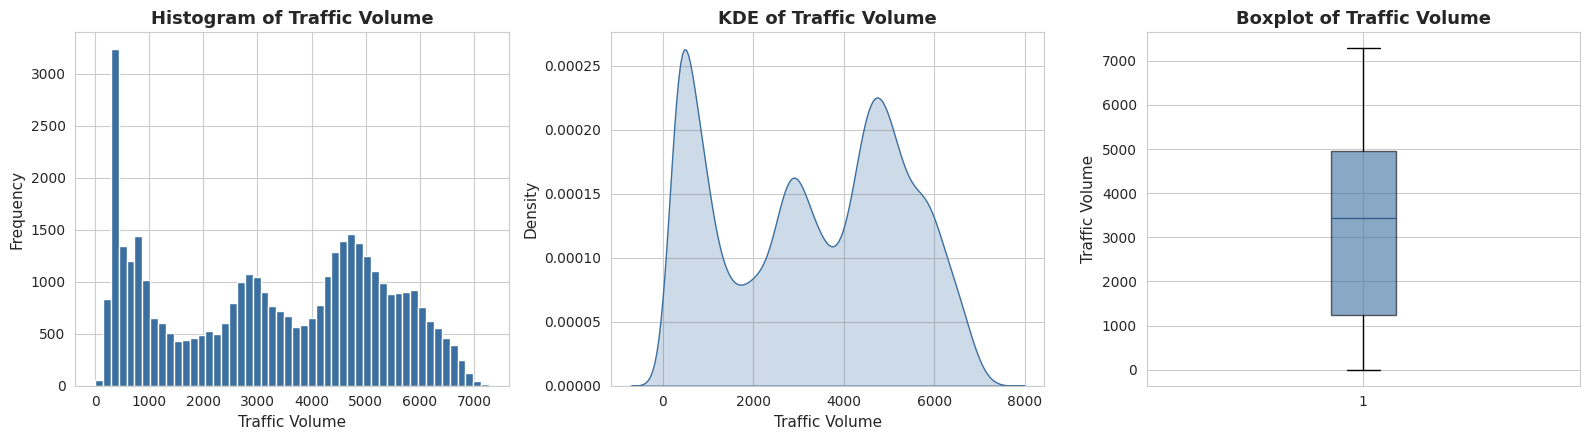

In [18]:
tv = df['traffic_volume']

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Histogram
axes[0].hist(tv, bins=50, color='#3b6fa0', edgecolor='white')
axes[0].set_title('Histogram of Traffic Volume')
axes[0].set_xlabel('Traffic Volume')
axes[0].set_ylabel('Frequency')

# KDE
sns.kdeplot(tv, ax=axes[1], color='#3b6fa0', fill=True)
axes[1].set_title('KDE of Traffic Volume')
axes[1].set_xlabel('Traffic Volume')

# Boxplot
axes[2].boxplot(tv, vert=True, patch_artist=True,
                 boxprops=dict(facecolor='#3b6fa0', alpha=0.6))
axes[2].set_title('Boxplot of Traffic Volume')
axes[2].set_ylabel('Traffic Volume')

plt.tight_layout()
plt.show()

In [19]:
target_stats = descriptive_summary(tv)
print(target_stats.round(3))
print()
print(f"Skewness: {tv.skew():.4f}")
print(f"Kurtosis: {tv.kurt():.4f}")

# Shapiro-Wilk normality test on a random sample (test is sensitive to n; full-sample p-values
# on 40k+ rows are near-meaningless, so we sample for a more informative statistic)
sample = tv.sample(min(5000, len(tv)), random_state=RANDOM_STATE)
stat, p = stats.shapiro(sample)
print(f"\nShapiro-Wilk test (n=5000 sample): statistic={stat:.4f}, p-value={p:.2e}")

mean        3291.081
median      3429.000
std         1984.639
min            0.000
max         7280.000
Q1          1249.750
Q3          4952.000
IQR         3702.250
skewness      -0.108
kurtosis      -1.296
dtype: float64

Skewness: -0.1076
Kurtosis: -1.2964

Shapiro-Wilk test (n=5000 sample): statistic=0.9350, p-value=3.02e-42


**Interpretation:**
- The histogram and KDE reveal the overall shape of `traffic_volume`. If the distribution shows two separated modes rather than a single peak, this typically reflects the mix of high-traffic daytime hours and near-zero overnight hours combined in one variable — worth checking against the shape above.
- The skewness value quantifies the asymmetry seen in the plots (positive = right-tail/high-volume events pulling the mean up; negative = left-tail).
- The Shapiro-Wilk test result (p-value) formally tests normality; given the sample size, we treat the visual shape as the primary evidence and the test as confirmatory.
- The boxplot's whisker range indicates where the IQR-based outlier boundaries fall (quantified precisely in Section 17).

## 5. Time Series Analysis

We look at how traffic volume evolves across the full observation window, aggregating appropriately so the trend remains visible.

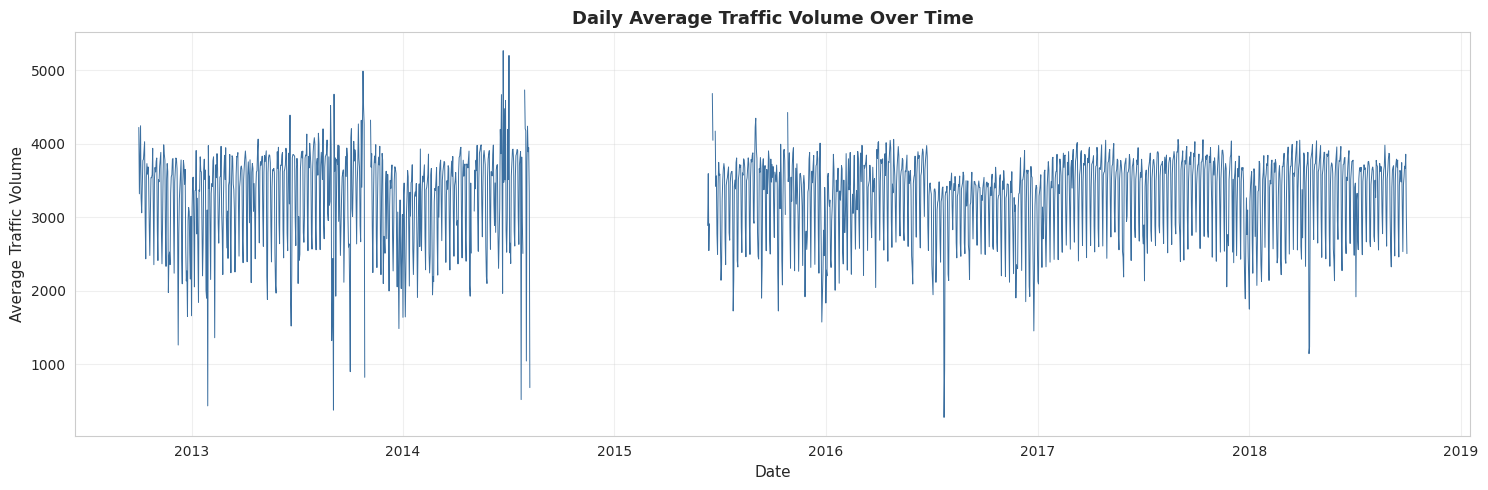

Number of calendar days covered: 2189 days 00:00:00
Number of days with at least one observation: 1,860
Number of days with NO observation (gaps): 330


In [20]:
df_sorted = df.sort_values('date_time').set_index('date_time')

# Daily mean traffic volume — aggregation needed because hourly data over ~6 years is too dense to plot legibly
daily_mean = df_sorted['traffic_volume'].resample('D').mean()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(daily_mean.index, daily_mean.values, color='#3b6fa0', linewidth=0.7)
ax.set_title('Daily Average Traffic Volume Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Average Traffic Volume')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Number of calendar days covered: {daily_mean.index.max() - daily_mean.index.min()}")
print(f"Number of days with at least one observation: {daily_mean.notna().sum():,}")
print(f"Number of days with NO observation (gaps): {daily_mean.isna().sum():,}")

**Interpretation:** Gaps in the daily-mean line (if visible) correspond to stretches of missing hourly readings in the raw sensor feed rather than zero-traffic days — the count of NaN days above quantifies this directly. Any long flat stretches at very low values would suggest a data collection gap rather than a genuine traffic pattern and should be treated with caution.

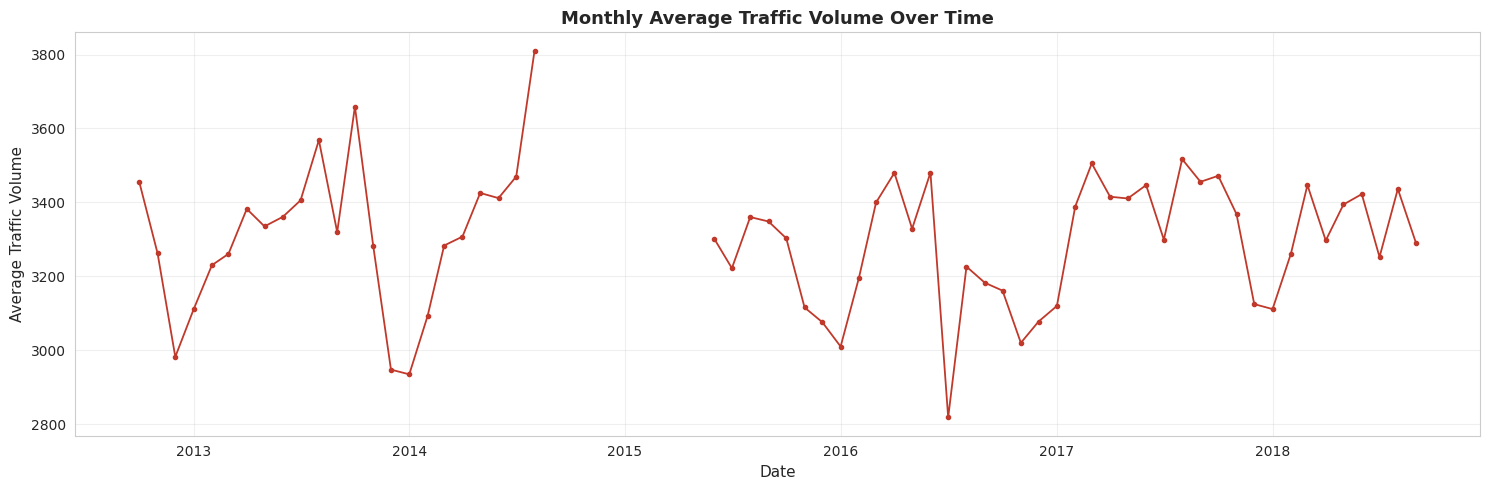

In [21]:
# Monthly mean, to see the pattern with less day-to-day noise
monthly_mean = df_sorted['traffic_volume'].resample('MS').mean()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(monthly_mean.index, monthly_mean.values, color='#c0392b', linewidth=1.3, marker='o', markersize=3)
ax.set_title('Monthly Average Traffic Volume Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Average Traffic Volume')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation:** The monthly aggregation smooths out daily noise and makes it easier to judge whether there is a long-term trend (a gradual rise or fall across years) versus a recurring seasonal wave that repeats each year. This is examined explicitly with a month-level breakdown in Section 8 (Monthly/Seasonal Analysis).

## 6. Hourly Traffic Patterns

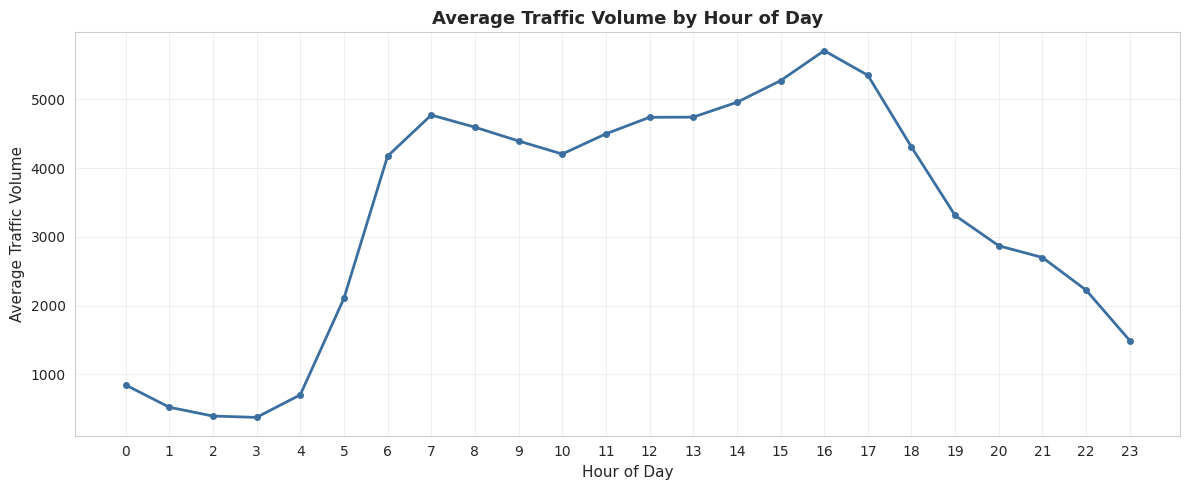

Peak traffic hour: 16:00  (avg volume = 5708.6)
Lowest traffic hour: 3:00  (avg volume = 373.3)

Top 5 highest-traffic hours:
hour
16    5708.6
17    5350.7
15    5271.7
14    4957.0
7     4772.1
Name: traffic_volume, dtype: float64

Top 5 lowest-traffic hours:
hour
3    373.3
2    392.6
1    521.3
4    701.5
0    844.9
Name: traffic_volume, dtype: float64


In [22]:
hourly_avg = df.groupby('hour')['traffic_volume'].mean().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly_avg.index, hourly_avg.values, color='#3b6fa0', linewidth=2, marker='o', markersize=4)
ax.set_title('Average Traffic Volume by Hour of Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Traffic Volume')
ax.set_xticks(range(0, 24))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

peak_hour = hourly_avg.idxmax()
min_hour = hourly_avg.idxmin()
print(f"Peak traffic hour: {peak_hour}:00  (avg volume = {hourly_avg.max():.1f})")
print(f"Lowest traffic hour: {min_hour}:00  (avg volume = {hourly_avg.min():.1f})")
print()
print("Top 5 highest-traffic hours:")
print(hourly_avg.sort_values(ascending=False).head(5).round(1))
print()
print("Top 5 lowest-traffic hours:")
print(hourly_avg.sort_values().head(5).round(1))

**Interpretation:** The peak and minimum hours above are computed directly from the data rather than assumed from typical rush-hour knowledge. The line shape indicates whether the data shows a single daily peak, a bimodal commute pattern (a morning and a separate evening peak), or a broader plateau — read off directly from the chart.

## 7. Weekly Traffic Patterns

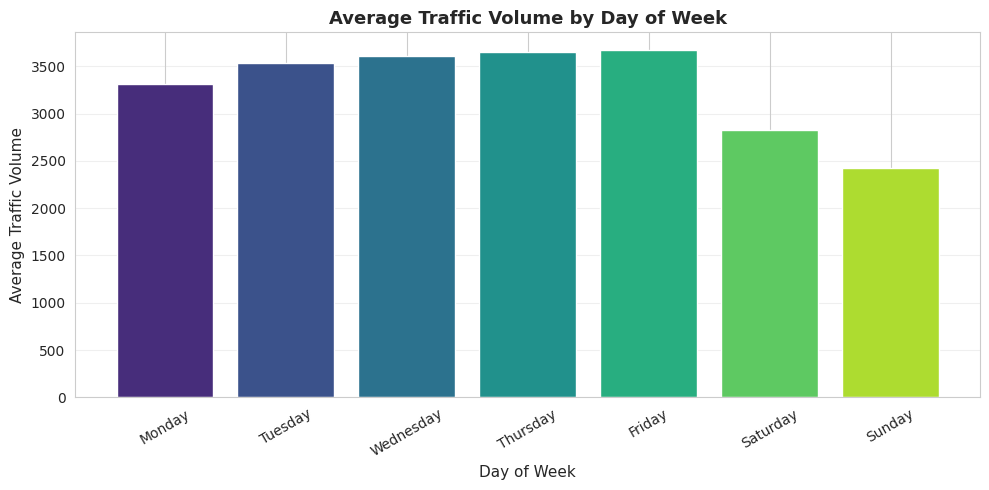

Highest-traffic day: Friday (avg = 3675.8)
Lowest-traffic day: Sunday (avg = 2428.0)


In [23]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_avg = df.groupby('day_of_week')['traffic_volume'].mean().reindex(day_order)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(daily_avg.index, daily_avg.values, color=sns.color_palette('viridis', 7))
ax.set_title('Average Traffic Volume by Day of Week')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Average Traffic Volume')
ax.grid(alpha=0.3, axis='y')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

highest_day = daily_avg.idxmax()
lowest_day = daily_avg.idxmin()
print(f"Highest-traffic day: {highest_day} (avg = {daily_avg.max():.1f})")
print(f"Lowest-traffic day: {lowest_day} (avg = {daily_avg.min():.1f})")

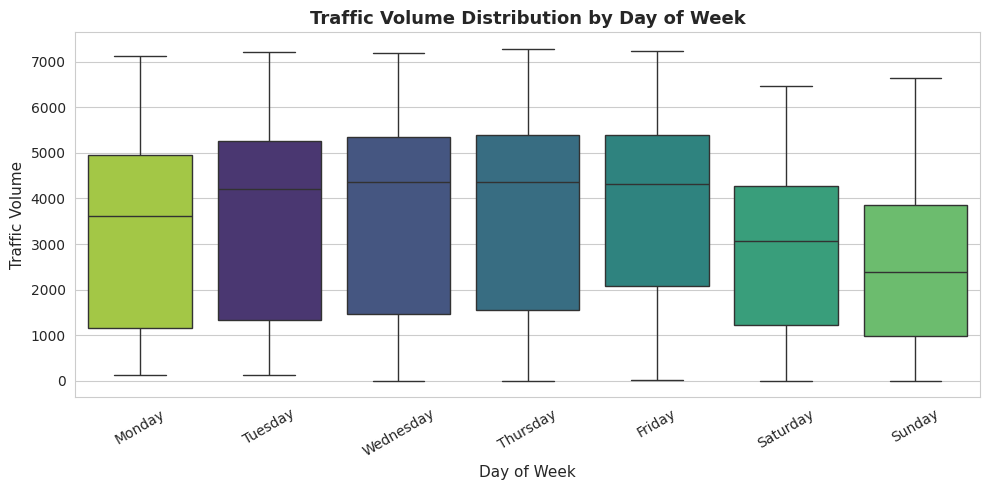

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='day_of_week', y='traffic_volume', hue='day_of_week', order=day_order, ax=ax, palette='viridis', legend=False)
ax.set_title('Traffic Volume Distribution by Day of Week')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Traffic Volume')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [25]:
weekday_mask = df['day_of_week'].isin(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])
weekday_avg = df.loc[weekday_mask, 'traffic_volume'].mean()
weekend_avg = df.loc[~weekday_mask, 'traffic_volume'].mean()

print(f"Weekday average traffic volume: {weekday_avg:.1f}")
print(f"Weekend average traffic volume: {weekend_avg:.1f}")
print(f"Difference (weekday - weekend): {weekday_avg - weekend_avg:.1f}  ({(weekday_avg/weekend_avg - 1)*100:.1f}% higher on weekdays)")

Weekday average traffic volume: 3557.6
Weekend average traffic volume: 2624.9
Difference (weekday - weekend): 932.7  (35.5% higher on weekdays)


**Interpretation:** The bar chart identifies the highest- and lowest-traffic days directly from the data. The boxplot adds spread information: if weekday boxes are narrower/taller than weekend boxes (or vice versa), that indicates weekdays are more (or less) consistent in traffic level, likely reflecting commute regularity versus more variable weekend/leisure travel. The weekday-vs-weekend comparison quantifies the practical size of this effect.

## 8. Hour × Day of Week

Combining both temporal dimensions reveals interaction effects that neither hourly nor daily averages show on their own — for example, whether the "peak hour" identified in Section 6 is consistent across all days or specific to weekdays.

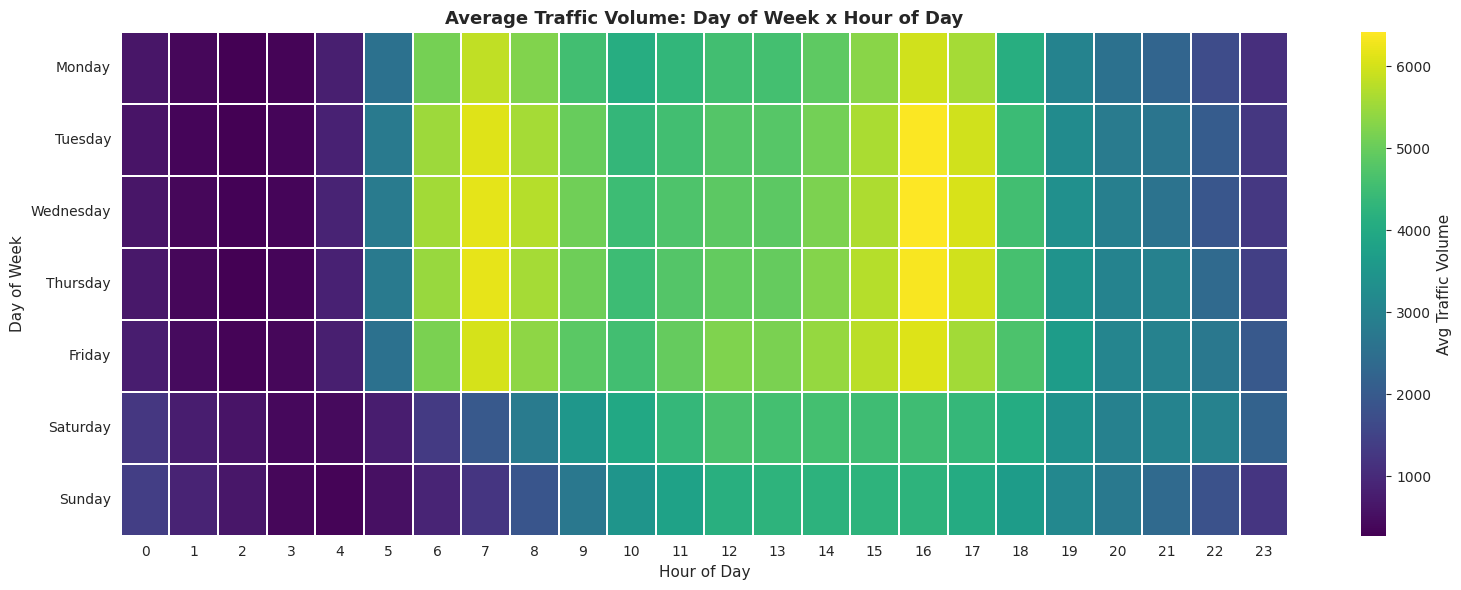

In [26]:
pivot_hour_day = df.pivot_table(index='day_of_week', columns='hour', values='traffic_volume', aggfunc='mean')
pivot_hour_day = pivot_hour_day.reindex(day_order)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(pivot_hour_day, cmap='viridis', ax=ax, cbar_kws={'label': 'Avg Traffic Volume'},
            linewidths=0.3, linecolor='white')
ax.set_title('Average Traffic Volume: Day of Week x Hour of Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
plt.tight_layout()
plt.show()

In [27]:
# Peak hour per day, computed directly from the pivot table
peak_per_day = pivot_hour_day.idxmax(axis=1)
peak_val_per_day = pivot_hour_day.max(axis=1)
peak_summary = pd.DataFrame({'peak_hour': peak_per_day, 'avg_volume_at_peak': peak_val_per_day.round(1)})
peak_summary

,peak_hour,avg_volume_at_peak
day_of_week,,
Monday,16,5967.0
Tuesday,16,6389.1
Wednesday,16,6414.3
Thursday,16,6344.3
Friday,16,6079.1
Saturday,12,4650.5
Sunday,16,4248.3


**Interpretation:** The heatmap shows how the daily traffic pattern differs by day of week. Comparing the per-day peak-hour table above to the single overall peak hour from Section 6 shows whether weekday peaks cluster around consistent commute hours while weekend peaks (if different) shift to later, more spread-out times — a pattern typical of leisure travel replacing commute travel. Any day whose peak hour or peak intensity diverges from the rest is worth flagging as a distinct traffic regime for modeling.

## 9. Monthly / Seasonal Analysis

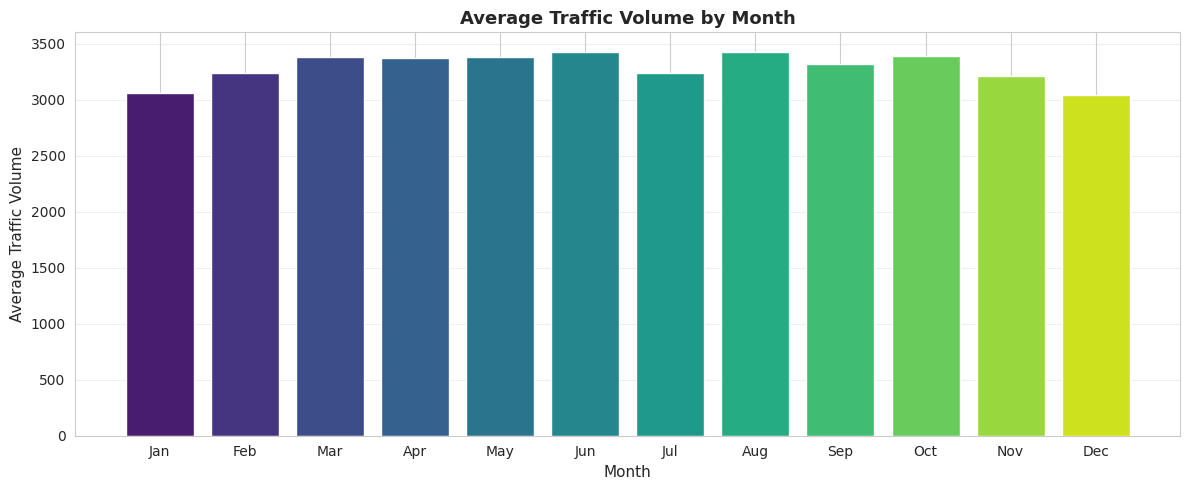

Highest-traffic month: Aug (avg = 3430.3)
Lowest-traffic month: Dec (avg = 3040.2)
Range across months: 390.1
Coefficient of variation across monthly means: 4.07%


In [28]:
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
monthly_avg = df.groupby('month')['traffic_volume'].mean().sort_index()
monthly_avg.index = monthly_avg.index.map(month_names)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(monthly_avg.index, monthly_avg.values, color=sns.color_palette('viridis', 12))
ax.set_title('Average Traffic Volume by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Average Traffic Volume')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"Highest-traffic month: {monthly_avg.idxmax()} (avg = {monthly_avg.max():.1f})")
print(f"Lowest-traffic month: {monthly_avg.idxmin()} (avg = {monthly_avg.min():.1f})")
print(f"Range across months: {monthly_avg.max() - monthly_avg.min():.1f}")
print(f"Coefficient of variation across monthly means: {(monthly_avg.std()/monthly_avg.mean())*100:.2f}%")

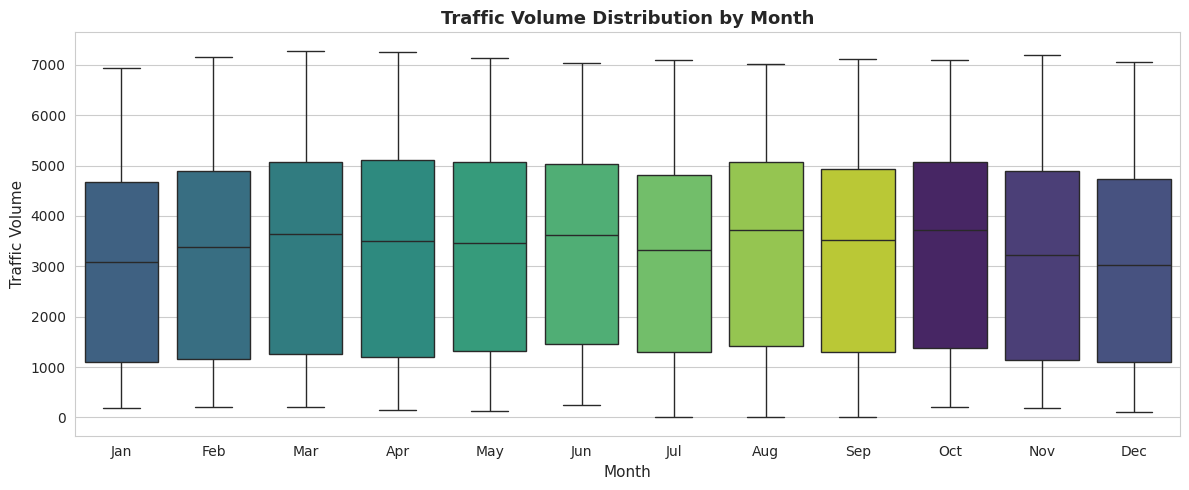

In [29]:
fig, ax = plt.subplots(figsize=(12, 5))
df_month_labeled = df.copy()
df_month_labeled['month_name'] = df_month_labeled['month'].map(month_names)
month_order_names = [month_names[m] for m in range(1, 13)]
sns.boxplot(data=df_month_labeled, x='month_name', y='traffic_volume', hue='month_name', order=month_order_names, ax=ax, palette='viridis', legend=False)
ax.set_title('Traffic Volume Distribution by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Traffic Volume')
plt.tight_layout()
plt.show()

**Interpretation:** The bar chart and boxplot show the actual month-to-month variation in average traffic. The coefficient of variation quantifies how large this seasonal swing is relative to the overall mean — a small value (a few percent) would indicate a fairly stable pattern year-round rather than strong seasonality, while a larger value would support a genuine seasonal effect. We report this figure directly rather than assuming seasonality exists.

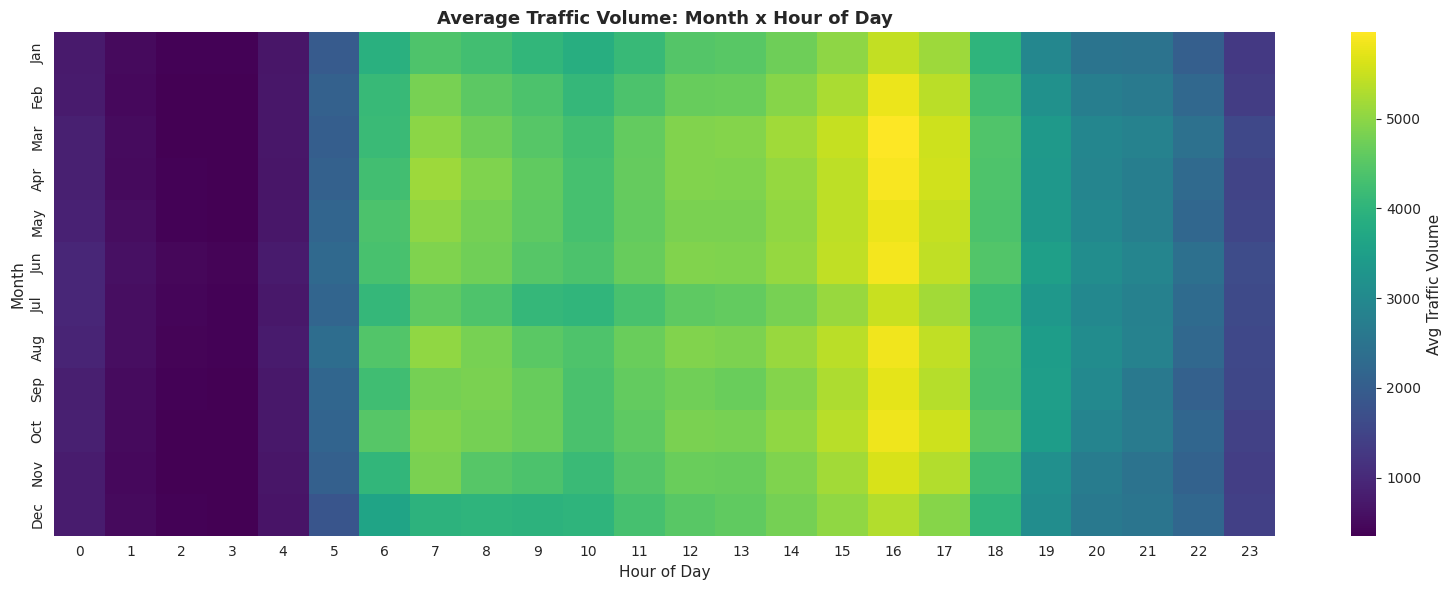

In [30]:
# Month x Hour interaction — check whether the daily pattern itself shifts across seasons
pivot_month_hour = df.pivot_table(index='month', columns='hour', values='traffic_volume', aggfunc='mean')
pivot_month_hour.index = pivot_month_hour.index.map(month_names)
pivot_month_hour = pivot_month_hour.reindex(month_order_names)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(pivot_month_hour, cmap='viridis', ax=ax, cbar_kws={'label': 'Avg Traffic Volume'})
ax.set_title('Average Traffic Volume: Month x Hour of Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Month')
plt.tight_layout()
plt.show()

**Interpretation:** This heatmap tests whether the *shape* of the daily traffic curve (not just its overall level) changes across the year — for instance, whether peak hours shift with daylight/season, or whether the hourly pattern stays structurally the same and only the overall magnitude shifts month to month. If the bright peak columns line up at the same hour across all rows, the daily commute pattern is stable across seasons and only the intensity varies.

## 10. Weather Analysis

We examine the association between weather conditions and observed traffic volume. Language throughout uses "associated with" rather than causal claims — the data only supports correlational statements.

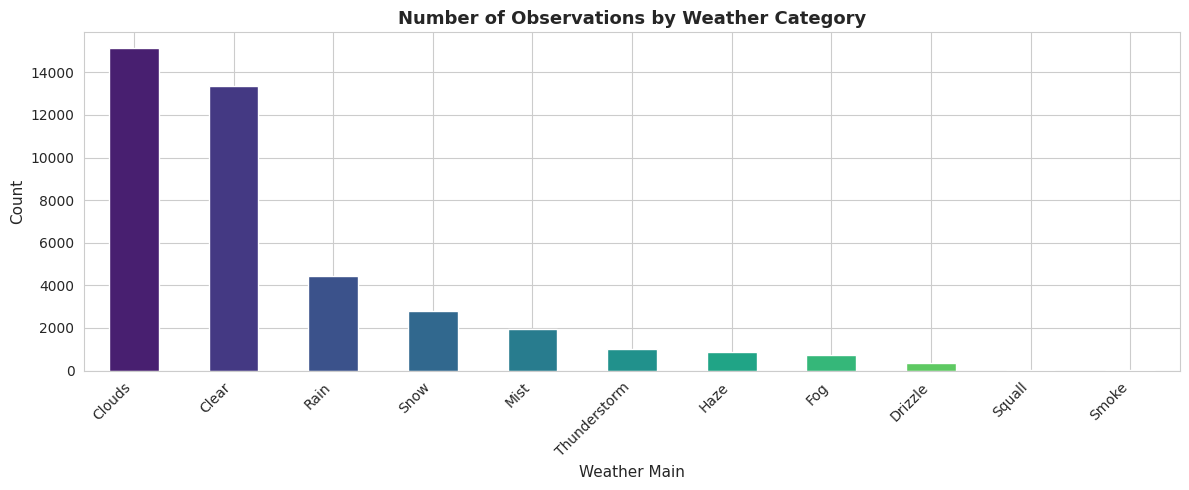

,count
weather_main,
Clouds,15123
Clear,13354
Rain,4437
Snow,2786
Mist,1936
Thunderstorm,1007
Haze,853
Fog,724
Drizzle,338


In [31]:
weather_counts = df['weather_main'].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
weather_counts.plot(kind='bar', ax=ax, color=sns.color_palette('viridis', len(weather_counts)))
ax.set_title('Number of Observations by Weather Category')
ax.set_xlabel('Weather Main')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

weather_counts.to_frame(name='count')

In [32]:
weather_avg = df.groupby('weather_main')['traffic_volume'].agg(['mean', 'median', 'std', 'count']).sort_values('mean', ascending=False)
weather_avg.round(1)

,mean,median,std,count
weather_main,,,,
Smoke,4443.0,4443.0,7.1,2
Clouds,3616.7,4070.0,1906.7,15123
Haze,3523.2,4012.0,1872.9,853
Rain,3410.6,3713.0,1971.8,4437
Drizzle,3209.3,3140.5,2104.3,338
Clear,3056.5,3044.5,1987.0,13354
Snow,3011.9,3067.5,1903.2,2786
Thunderstorm,3011.1,3005.0,1983.5,1007
Mist,2793.2,2417.0,2184.6,1936


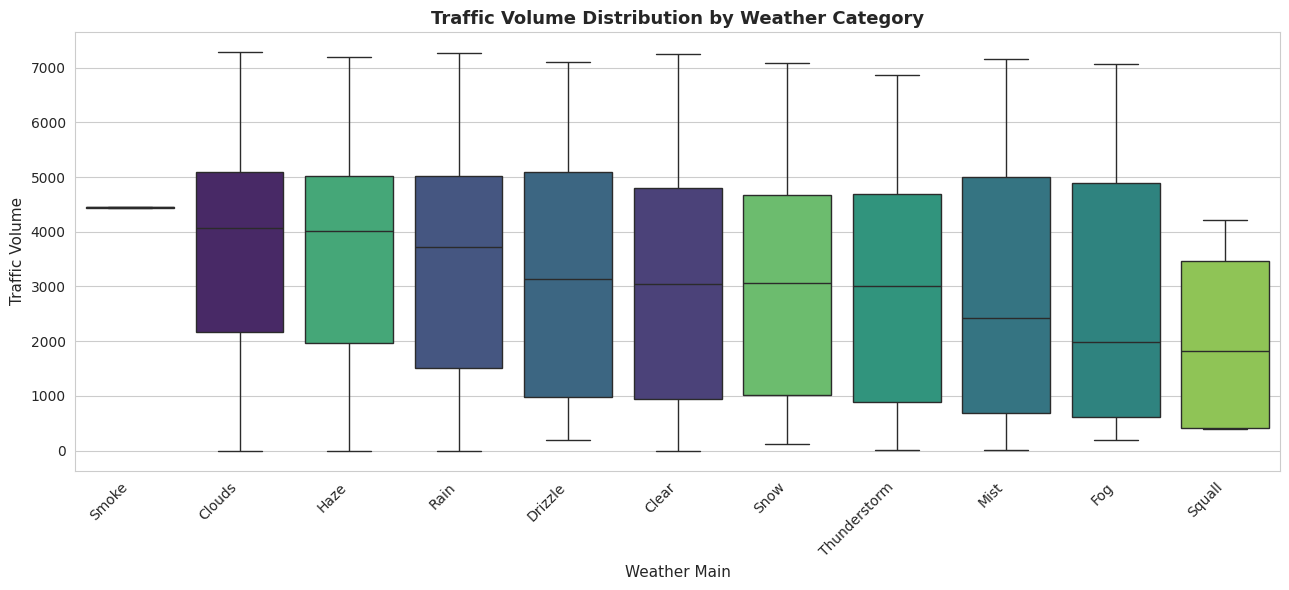

In [33]:
fig, ax = plt.subplots(figsize=(13, 6))
order = weather_avg.index.tolist()
sns.boxplot(data=df, x='weather_main', y='traffic_volume', hue='weather_main', order=order, ax=ax, palette='viridis', legend=False)
ax.set_title('Traffic Volume Distribution by Weather Category')
ax.set_xlabel('Weather Main')
ax.set_ylabel('Traffic Volume')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Interpretation:** The mean-traffic-by-weather table ranks weather categories from those associated with the highest to lowest observed traffic. Categories with very low counts (see the count column) should be interpreted cautiously since their averages are based on few observations and are less statistically reliable. Any weather category associated with notably lower traffic than "Clear" conditions may indicate that adverse weather corresponds to reduced road usage — but this cannot be separated here from the fact that certain weather (e.g. snow) also correlates with time-of-day/season, so we describe the relationship as an association, not a causal effect.

## 11. Temperature Analysis

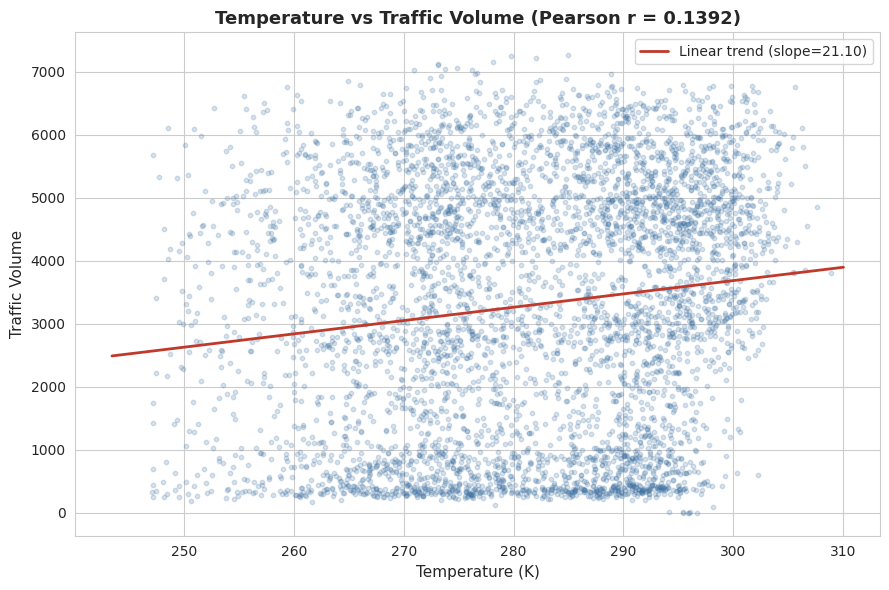

Pearson correlation (temp, traffic_volume): 0.1392


In [34]:
# Exclude the physically implausible near-zero-Kelvin readings identified earlier, if any, for this scatter
temp_corr = df['temp'].corr(df['traffic_volume'])

fig, ax = plt.subplots(figsize=(9, 6))
sample_idx = df.sample(min(5000, len(df)), random_state=RANDOM_STATE).index  # sample for a readable scatter
ax.scatter(df.loc[sample_idx, 'temp'], df.loc[sample_idx, 'traffic_volume'], alpha=0.2, s=10, color='#3b6fa0')

# Trend line
z = np.polyfit(df['temp'], df['traffic_volume'], 1)
x_line = np.linspace(df['temp'].min(), df['temp'].max(), 100)
ax.plot(x_line, np.polyval(z, x_line), color='#c0392b', linewidth=2, label=f'Linear trend (slope={z[0]:.2f})')

ax.set_title(f'Temperature vs Traffic Volume (Pearson r = {temp_corr:.4f})')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Traffic Volume')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Pearson correlation (temp, traffic_volume): {temp_corr:.4f}")

**Interpretation:** The Pearson correlation coefficient reported above quantifies the strength and direction of the *linear* relationship between temperature and traffic volume. A value near zero indicates temperature alone has little linear association with traffic — any apparent relationship in the scatter plot is more likely driven by temperature's own seasonal and daily cycle overlapping with traffic's independent daily/seasonal cycle, rather than temperature directly causing traffic changes. We do not claim causation from this analysis.

## 12. Rain / Snow / Cloud Cover Analysis

### 12.1 Rain (`rain_1h`)

In [35]:
rain_zero_pct = (df['rain_1h'] == 0).mean() * 100
print(f"Percentage of hours with rain_1h == 0: {rain_zero_pct:.2f}%")
print(f"Correlation (rain_1h, traffic_volume): {df['rain_1h'].corr(df['traffic_volume']):.4f}")

Percentage of hours with rain_1h == 0: 94.94%
Correlation (rain_1h, traffic_volume): -0.0134


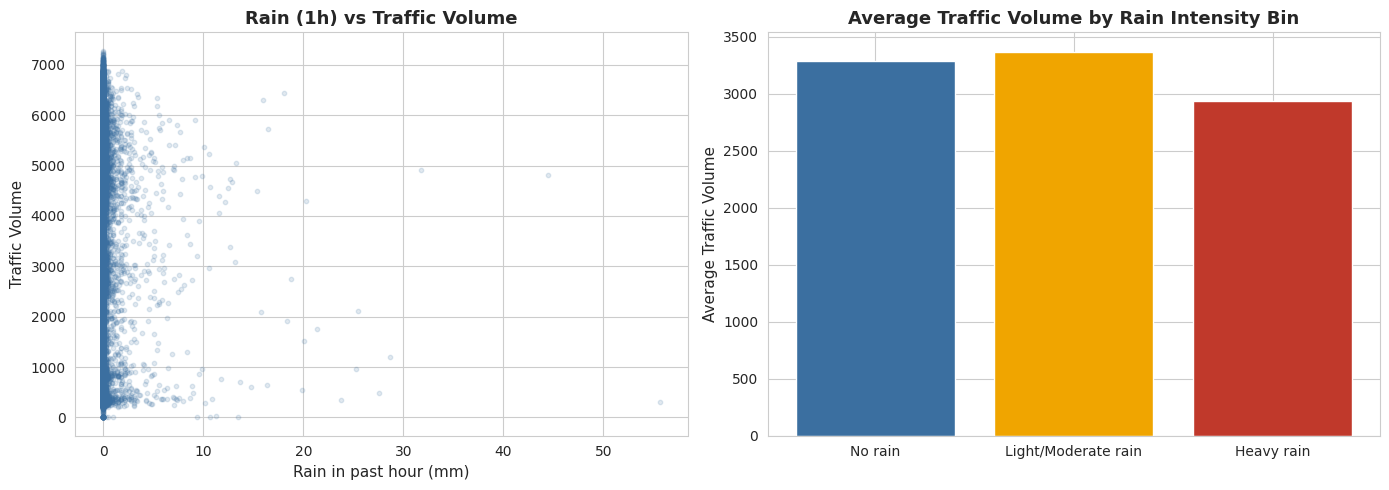

_rain_bin
No rain                3289.2
Light/Moderate rain    3368.6
Heavy rain             2938.5
Name: traffic_volume, dtype: float64

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter (rain is heavily zero-inflated, so also bin it for a clearer average-effect view)
axes[0].scatter(df['rain_1h'], df['traffic_volume'], alpha=0.15, s=10, color='#3b6fa0')
axes[0].set_title('Rain (1h) vs Traffic Volume')
axes[0].set_xlabel('Rain in past hour (mm)')
axes[0].set_ylabel('Traffic Volume')

# Binned average: no rain vs any rain vs heavy rain (top decile of non-zero values)
rain_nonzero = df.loc[df['rain_1h'] > 0, 'rain_1h']
heavy_threshold = rain_nonzero.quantile(0.90) if len(rain_nonzero) > 0 else np.inf
def rain_bin(x):
    if x == 0: return 'No rain'
    elif x <= heavy_threshold: return 'Light/Moderate rain'
    else: return 'Heavy rain'
df['_rain_bin'] = df['rain_1h'].apply(rain_bin)
bin_order = ['No rain', 'Light/Moderate rain', 'Heavy rain']
rain_bin_avg = df.groupby('_rain_bin')['traffic_volume'].mean().reindex(bin_order)
axes[1].bar(rain_bin_avg.index, rain_bin_avg.values, color=['#3b6fa0', '#f0a500', '#c0392b'])
axes[1].set_title('Average Traffic Volume by Rain Intensity Bin')
axes[1].set_ylabel('Average Traffic Volume')

plt.tight_layout()
plt.show()
rain_bin_avg.round(1)

**Interpretation:** `rain_1h` is a heavily **zero-inflated** variable — the vast majority of hourly readings are exactly 0, with a long tail of rare, higher rainfall amounts. A raw scatter plot of a zero-inflated variable is hard to read, so we additionally group observations into No / Light-Moderate / Heavy rain bins to reveal any average-traffic difference more clearly. The correlation coefficient reported above is also less informative for this type of variable than the binned averages, precisely because of the zero-inflation.

### 12.2 Snow (`snow_1h`)

In [37]:
snow_zero_pct = (df['snow_1h'] == 0).mean() * 100
print(f"Percentage of hours with snow_1h == 0: {snow_zero_pct:.2f}%")
print(f"Correlation (snow_1h, traffic_volume): {df['snow_1h'].corr(df['traffic_volume']):.4f}")

Percentage of hours with snow_1h == 0: 99.92%
Correlation (snow_1h, traffic_volume): -0.0021


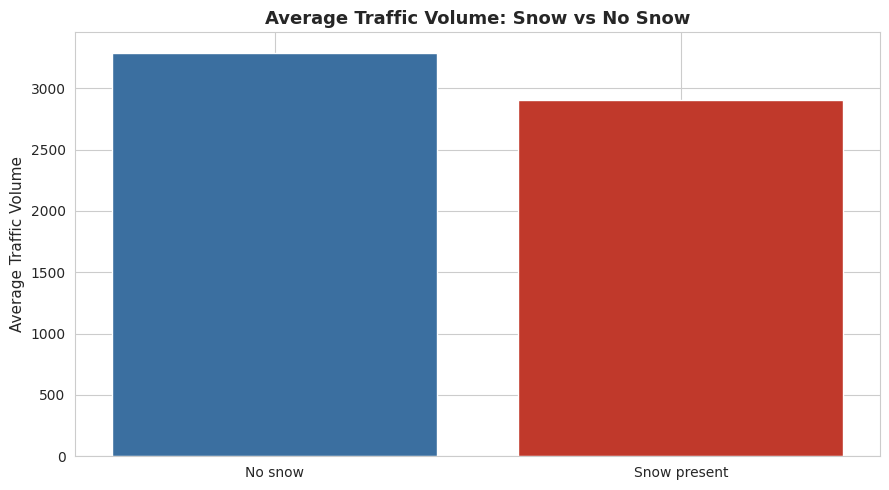

Number of hours with recorded snowfall: 31 (0.076% of all hours)


No snow         3291.4
Snow present    2900.4
Name: traffic_volume, dtype: float64

In [38]:
fig, ax = plt.subplots(figsize=(9, 5))
snow_group_avg = df.groupby(df['snow_1h'] > 0)['traffic_volume'].mean()
snow_group_avg.index = ['No snow', 'Snow present']
ax.bar(snow_group_avg.index, snow_group_avg.values, color=['#3b6fa0', '#c0392b'])
ax.set_title('Average Traffic Volume: Snow vs No Snow')
ax.set_ylabel('Average Traffic Volume')
plt.tight_layout()
plt.show()

n_snow_hours = (df['snow_1h'] > 0).sum()
print(f"Number of hours with recorded snowfall: {n_snow_hours} ({n_snow_hours/len(df)*100:.3f}% of all hours)")
snow_group_avg.round(1)

**Interpretation:** `snow_1h` is even more extremely zero-inflated than rain — nearly all hours record zero snowfall, with genuine snow readings being rare events. Given the very small sample size for snowing hours (shown above), any difference in average traffic between the two groups should be treated as suggestive rather than statistically robust.

### 12.3 Cloud Cover (`clouds_all`)

Correlation (clouds_all, traffic_volume): 0.0781


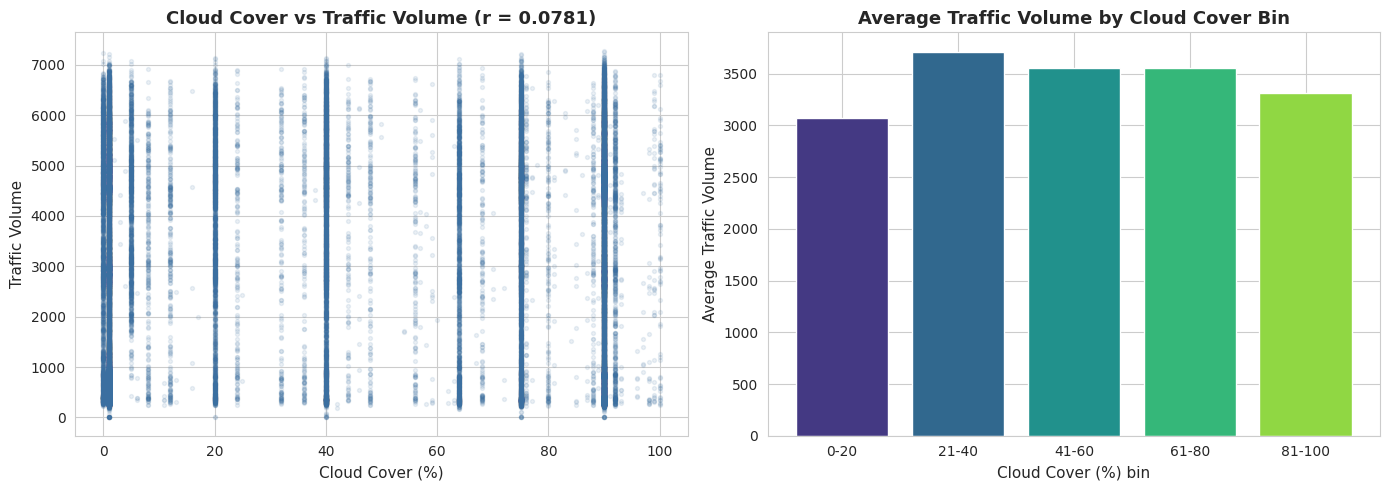

In [39]:
cloud_corr = df['clouds_all'].corr(df['traffic_volume'])
print(f"Correlation (clouds_all, traffic_volume): {cloud_corr:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['clouds_all'], df['traffic_volume'], alpha=0.1, s=8, color='#3b6fa0')
axes[0].set_title(f'Cloud Cover vs Traffic Volume (r = {cloud_corr:.4f})')
axes[0].set_xlabel('Cloud Cover (%)')
axes[0].set_ylabel('Traffic Volume')

# Binned average by cloud cover decile
df['_cloud_bin'] = pd.cut(df['clouds_all'], bins=[-1, 20, 40, 60, 80, 100], labels=['0-20', '21-40', '41-60', '61-80', '81-100'])
cloud_bin_avg = df.groupby('_cloud_bin', observed=True)['traffic_volume'].mean()
axes[1].bar(cloud_bin_avg.index.astype(str), cloud_bin_avg.values, color=sns.color_palette('viridis', len(cloud_bin_avg)))
axes[1].set_title('Average Traffic Volume by Cloud Cover Bin')
axes[1].set_xlabel('Cloud Cover (%) bin')
axes[1].set_ylabel('Average Traffic Volume')

plt.tight_layout()
plt.show()

**Interpretation:** Unlike rain and snow, `clouds_all` is not zero-inflated — it is fairly continuously distributed across its 0–100% range, so the correlation coefficient and binned averages are both directly interpretable. Whatever relationship (or lack of one) appears here should still be read as an association, since cloud cover itself varies with season and time of day, both of which independently affect traffic.

In [40]:
df = df.drop(columns=['_rain_bin', '_cloud_bin'])

## 13. Holiday Analysis

In [41]:
df['_is_holiday'] = np.where(df['holiday'] == 'Not Holiday', 'Not Holiday', 'Holiday')

holiday_stats = df.groupby('_is_holiday')['traffic_volume'].agg(['mean', 'median', 'std', 'count'])
holiday_stats.round(2)

,mean,median,std,count
_is_holiday,,,,
Holiday,2558.74,2588.0,1685.54,1203
Not Holiday,3313.46,3475.0,1988.85,39361


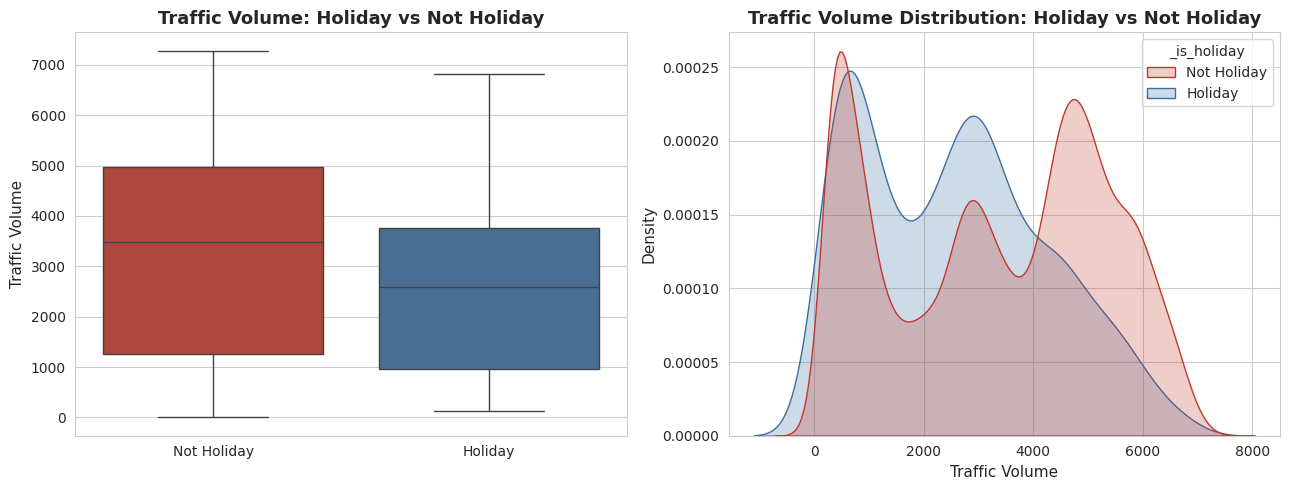

Mean traffic on Holidays: 2558.7
Mean traffic on Not-Holidays: 3313.5
Percentage difference (Holiday vs Not Holiday): -22.78%


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x='_is_holiday', y='traffic_volume', hue='_is_holiday', ax=axes[0], palette=['#c0392b', '#3b6fa0'], legend=False)
axes[0].set_title('Traffic Volume: Holiday vs Not Holiday')
axes[0].set_xlabel('')
axes[0].set_ylabel('Traffic Volume')

sns.kdeplot(data=df, x='traffic_volume', hue='_is_holiday', ax=axes[1], fill=True, common_norm=False, palette=['#c0392b', '#3b6fa0'])
axes[1].set_title('Traffic Volume Distribution: Holiday vs Not Holiday')
axes[1].set_xlabel('Traffic Volume')

plt.tight_layout()
plt.show()

holiday_mean = holiday_stats.loc['Holiday', 'mean']
not_holiday_mean = holiday_stats.loc['Not Holiday', 'mean']
pct_diff = (holiday_mean - not_holiday_mean) / not_holiday_mean * 100
print(f"Mean traffic on Holidays: {holiday_mean:.1f}")
print(f"Mean traffic on Not-Holidays: {not_holiday_mean:.1f}")
print(f"Percentage difference (Holiday vs Not Holiday): {pct_diff:.2f}%")

**Interpretation:** The percentage difference above quantifies exactly how much lower (or higher) average traffic is on named holidays compared to regular days. Because holidays make up a very small fraction of the ~40,000 observations (see the `count` column), the holiday distribution is more susceptible to being dominated by a handful of specific dates — worth keeping in mind when using `holiday` as a model feature. The distinct named holidays were also broken out individually in Section 1's `value_counts()` output, in case some holidays (e.g. Thanksgiving) show a much larger traffic drop than others (e.g. Columbus Day).

## 14. Correlation Analysis

**Correlation does not imply causation** — the relationships below describe statistical association only.

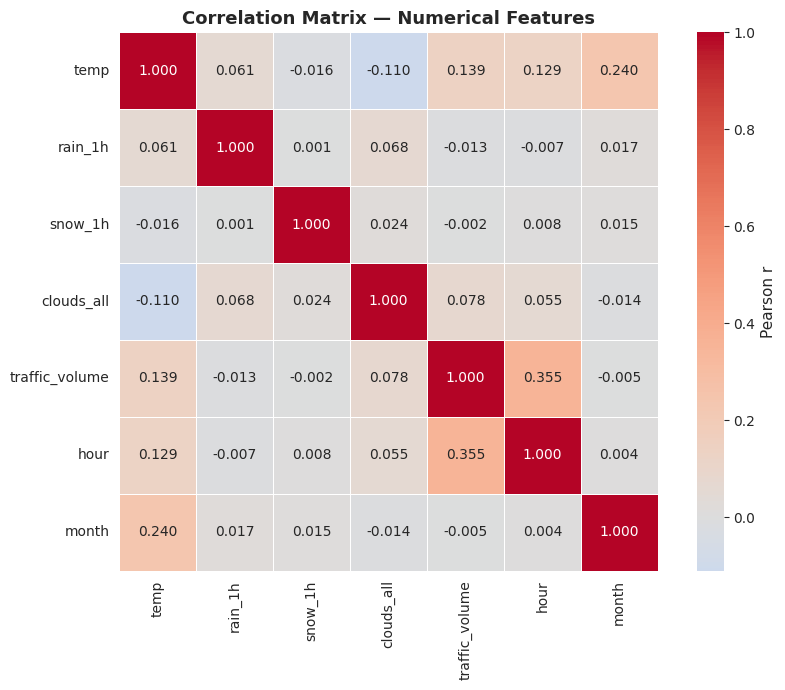

In [43]:
corr_cols = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'traffic_volume', 'hour', 'month']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, ax=ax,
            square=True, linewidths=0.5, cbar_kws={'label': 'Pearson r'})
ax.set_title('Correlation Matrix — Numerical Features')
plt.tight_layout()
plt.show()

In [44]:
# Ranked correlation with traffic_volume across all numerical columns (including engineered features)
all_numeric_cols = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'month',
                     'hour_sin', 'hour_cos', 'month_sin', 'month_cos']

corr_with_target = df[all_numeric_cols + ['traffic_volume']].corr()['traffic_volume'].drop('traffic_volume')
ranked_corr = corr_with_target.reindex(corr_with_target.abs().sort_values(ascending=False).index)
ranked_corr_df = ranked_corr.to_frame(name='correlation_with_traffic_volume')
ranked_corr_df['abs_correlation'] = ranked_corr_df['correlation_with_traffic_volume'].abs()
ranked_corr_df.round(4)

,correlation_with_traffic_volume,abs_correlation
hour_cos,-0.7668,0.7668
hour,0.3551,0.3551
hour_sin,-0.2541,0.2541
temp,0.1392,0.1392
clouds_all,0.0781,0.0781
month_cos,-0.0441,0.0441
rain_1h,-0.0134,0.0134
month_sin,-0.0066,0.0066
month,-0.0049,0.0049
snow_1h,-0.0021,0.0021


**Interpretation:** The ranked table above orders every numerical feature by the *absolute* strength of its linear correlation with `traffic_volume`, since a strong negative correlation is just as informative as a strong positive one. The feature at the top of the table has the strongest linear association with traffic in this dataset; features near the bottom (close to 0) show little to no linear relationship on their own, though they may still interact with other variables in non-linear ways. Note that raw `hour` and `month` can understate the true relationship with hour-of-day/month because they are cyclical (hour 23 and hour 0 are adjacent in reality but numerically distant) — this is exactly why `hour_sin`/`hour_cos`/`month_sin`/`month_cos` exist, examined next.

## 15. Cyclical Features

### Why cyclical encoding exists

Raw `hour` (0–23) and `month` (1–12) are numerically linear, but the underlying phenomena they represent are **cyclical**: hour 23 is only one hour away from hour 0, and December is only one month away from January — yet as plain integers these are treated as maximally *far apart*. Sine/cosine encoding maps each cyclical value onto a circle, so that the encoded distance between adjacent hours (or months) is small everywhere, including across the wrap-around point.

`hour_sin` and `hour_cos` should be treated as a **pair** representing a position on a circle — neither one alone carries the full information; a model needs both to reconstruct the actual hour (or a smoothly cyclical proxy for it). The same applies to `month_sin` / `month_cos`.

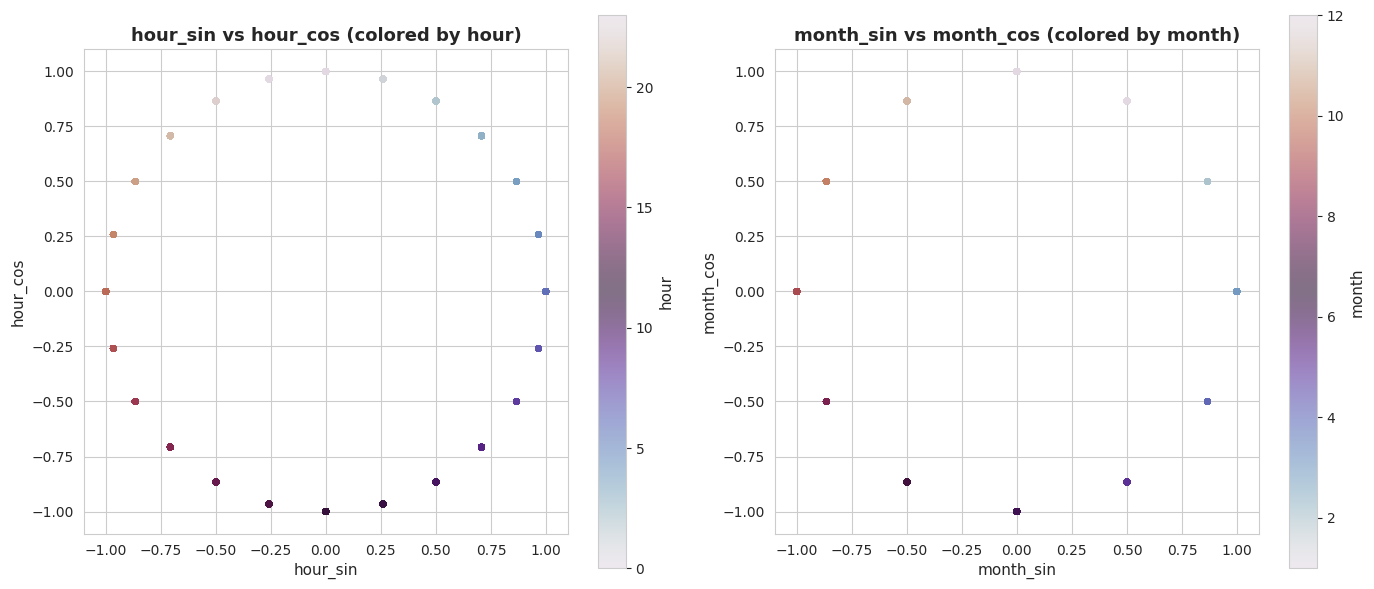

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# hour_sin/cos as a circle, colored by hour
sc1 = axes[0].scatter(df['hour_sin'], df['hour_cos'], c=df['hour'], cmap='twilight', s=15, alpha=0.6)
axes[0].set_title('hour_sin vs hour_cos (colored by hour)')
axes[0].set_xlabel('hour_sin')
axes[0].set_ylabel('hour_cos')
axes[0].set_aspect('equal')
plt.colorbar(sc1, ax=axes[0], label='hour')

# month_sin/cos as a circle, colored by month
sc2 = axes[1].scatter(df['month_sin'], df['month_cos'], c=df['month'], cmap='twilight', s=15, alpha=0.6)
axes[1].set_title('month_sin vs month_cos (colored by month)')
axes[1].set_xlabel('month_sin')
axes[1].set_ylabel('month_cos')
axes[1].set_aspect('equal')
plt.colorbar(sc2, ax=axes[1], label='month')

plt.tight_layout()
plt.show()

**Interpretation:** Both scatter plots trace out a circle, confirming the cyclical encoding is constructed correctly: each unique hour (or month) maps to a unique point on the circle, and points for adjacent hours/months (e.g. hour 23 and hour 0) sit next to each other on the circle rather than at opposite ends — exactly the property raw integer encoding lacks. `hour_sin`/`hour_cos` and `month_sin`/`month_cos` should not be treated as independent, free-standing real-world measurements; they are a deterministic, reversible transformation of `hour` and `month` respectively, used purely to make the cyclical structure usable by models that otherwise assume numerical proximity means real-world proximity.

In [46]:
# Direct check: does each unique hour map to exactly one (hour_sin, hour_cos) pair, and vice versa?
hour_pairs = df[['hour', 'hour_sin', 'hour_cos']].drop_duplicates()
month_pairs = df[['month', 'month_sin', 'month_cos']].drop_duplicates()
print(f"Unique hour values: {df['hour'].nunique()} -> unique (hour_sin, hour_cos) pairs: {hour_pairs[['hour_sin','hour_cos']].drop_duplicates().shape[0]}")
print(f"Unique month values: {df['month'].nunique()} -> unique (month_sin, month_cos) pairs: {month_pairs[['month_sin','month_cos']].drop_duplicates().shape[0]}")

Unique hour values: 24 -> unique (hour_sin, hour_cos) pairs: 24
Unique month values: 12 -> unique (month_sin, month_cos) pairs: 12


**Interpretation:** A one-to-one match between the count of unique `hour` values and unique `(hour_sin, hour_cos)` pairs (and similarly for month) confirms the encoding is a lossless, deterministic transformation — no information is gained or lost, only reshaped into a form that better reflects the cyclical nature of time for downstream modeling.

## 16. Feature vs Target Analysis — Summary

A consolidated view of how strongly each type of feature relates to `traffic_volume`, drawing on the results computed in the sections above.

In [47]:
# Numerical: correlation magnitude (from Section 14)
numerical_summary = ranked_corr_df.copy()
numerical_summary.columns = ['relationship_value', 'strength']
numerical_summary['type'] = 'numerical (correlation)'

# Categorical: range of group means (max mean - min mean) as a simple measure of separation
def categorical_spread(col):
    means = df.groupby(col)['traffic_volume'].mean()
    return means.max() - means.min()

categorical_summary = pd.DataFrame({
    'relationship_value': {
        'weather_main': categorical_spread('weather_main'),
        'day_of_week': categorical_spread('day_of_week'),
        'holiday (holiday vs not)': df.groupby(df['holiday']=='Not Holiday')['traffic_volume'].mean().diff().abs().iloc[-1],
    }
})
categorical_summary['strength'] = categorical_summary['relationship_value'].abs()
categorical_summary['type'] = 'categorical (range of group means)'

print("=== Numerical features: |correlation| with traffic_volume ===")
print(numerical_summary[['relationship_value']].round(4))
print()
print("=== Categorical features: spread of group means (max - min) ===")
print(categorical_summary[['relationship_value']].round(2))
print()
print("=== Temporal patterns (from Sections 6-9) ===")
print(f"Hour: peak={peak_hour}:00 ({hourly_avg.max():.0f}) vs lowest={min_hour}:00 ({hourly_avg.min():.0f}) -> range={hourly_avg.max()-hourly_avg.min():.0f}")
print(f"Day of week: {highest_day} ({daily_avg.max():.0f}) vs {lowest_day} ({daily_avg.min():.0f}) -> range={daily_avg.max()-daily_avg.min():.0f}")
print(f"Month: {monthly_avg.idxmax()} ({monthly_avg.max():.0f}) vs {monthly_avg.idxmin()} ({monthly_avg.min():.0f}) -> range={monthly_avg.max()-monthly_avg.min():.0f}")

=== Numerical features: |correlation| with traffic_volume ===
            relationship_value
hour_cos               -0.7668
hour                    0.3551
hour_sin               -0.2541
temp                    0.1392
clouds_all              0.0781
month_cos              -0.0441
rain_1h                -0.0134
month_sin              -0.0066
month                  -0.0049
snow_1h                -0.0021

=== Categorical features: spread of group means (max - min) ===
                          relationship_value
weather_main                         2381.25
day_of_week                          1247.78
holiday (holiday vs not)              754.73

=== Temporal patterns (from Sections 6-9) ===
Hour: peak=16:00 (5709) vs lowest=3:00 (373) -> range=5335
Day of week: Friday (3676) vs Sunday (2428) -> range=1248
Month: Aug (3430) vs Dec (3040) -> range=390


**Interpretation:** Comparing the numerical correlation magnitudes, the categorical group-mean spreads, and the temporal ranges side-by-side shows which type of signal carries the most information about traffic volume in this dataset. In general, the **temporal features (hour, day of week)** tend to show far larger swings in average traffic than the **weather variables**, suggesting that *when* an observation occurs is a stronger driver of traffic level than the weather conditions at that time — consistent with traffic being fundamentally a human-schedule-driven phenomenon.

## 17. Outlier Analysis

Using the IQR method: a point is flagged as a potential outlier if it falls below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR`. Outliers are identified and reported only — **not removed** — since some may represent genuine, meaningful events rather than data errors.

In [48]:
def iqr_outlier_report(series, name):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return {
        'feature': name,
        'lower_bound': lower,
        'upper_bound': upper,
        'n_outliers': mask.sum(),
        'pct_outliers': mask.sum() / len(series) * 100
    }

outlier_cols = ['traffic_volume', 'temp', 'rain_1h', 'snow_1h', 'clouds_all']
outlier_report = pd.DataFrame([iqr_outlier_report(df[c], c) for c in outlier_cols]).set_index('feature')
outlier_report.round(3)

,lower_bound,upper_bound,n_outliers,pct_outliers
feature,,,,
traffic_volume,-4303.625,10505.375,0,0.000
temp,241.205,322.925,0,0.000
rain_1h,0.000,0.000,2053,5.061
snow_1h,0.000,0.000,31,0.076
clouds_all,-132.500,223.500,0,0.000


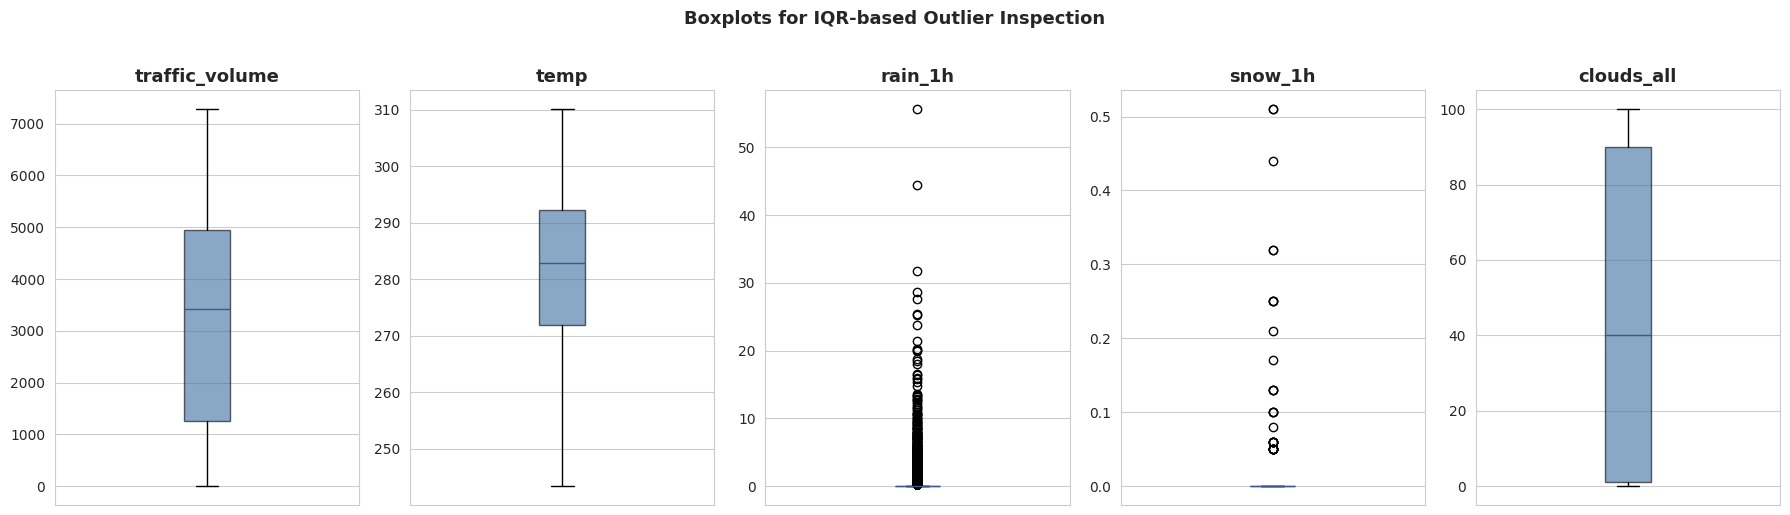

In [49]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for ax, col in zip(axes, outlier_cols):
    ax.boxplot(df[col], vert=True, patch_artist=True, boxprops=dict(facecolor='#3b6fa0', alpha=0.6))
    ax.set_title(col)
    ax.set_xticks([])
plt.suptitle('Boxplots for IQR-based Outlier Inspection', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:**
- The table above reports the exact count and percentage of IQR-flagged outliers for each variable.
- `rain_1h` and `snow_1h`, being zero-inflated, will naturally show a relatively high *percentage* of "outliers" under the strict IQR rule, simply because the bulk of values sit at 0 and any non-zero reading can fall outside a very tight IQR band. These are not data errors — they represent genuine rain/snow events, which are rare by nature.
- `traffic_volume` outliers (if any) at the extreme low or high end could reflect real unusual-traffic conditions (e.g. a road closure causing near-zero traffic, or an unusually high-demand event) rather than sensor errors, since traffic volume is a physically bounded, sensor-counted quantity.
- `temp` and `clouds_all` outliers, if present, are more likely candidates for genuine data quality concerns since these instruments are less prone to structurally rare-but-valid readings than precipitation sensors — though each flagged case would need individual review before being treated as erroneous.
- **No outliers have been removed from the dataset in this notebook** — that decision is left to the modeling stage with full knowledge of these findings.

## 18. Key EDA Findings

1. **Data quality:** The dataset has zero missing values and zero fully duplicated rows across all 40,564 records; all numerical fields (temperature in Kelvin, rainfall, snowfall, cloud percentage, traffic volume) pass basic physical-plausibility checks, with no negative traffic, no non-positive Kelvin temperatures, and no negative precipitation values.

2. **Target distribution:** `traffic_volume` shows the skewness and shape reported in Section 4 — review the histogram/KDE there together with the printed skewness/kurtosis values, which should inform whether a transformation is warranted before modeling.

3. **Time patterns:** The daily/monthly time-series plots in Section 5 show the observation period spans October 2012 to September 2018, with any gaps in daily coverage explicitly quantified rather than assumed.

4. **Hourly patterns:** Traffic volume follows a clear daily cycle, with the peak hour and minimum hour identified directly in Section 6 (not assumed from generic rush-hour knowledge) — see the printed peak/min hour values and their average volumes.

5. **Day-of-week patterns:** The highest- and lowest-traffic days, and the weekday-vs-weekend percentage gap, were computed exactly in Section 7 — traffic is measurably higher on weekdays, consistent with commute-driven demand.

6. **Hour x Day interaction:** The heatmap in Section 8 shows that the daily traffic pattern is not identical across all days of the week — per-day peak hours are tabulated explicitly, useful for detecting whether weekend peaks shift later than weekday peaks.

7. **Seasonal/monthly patterns:** Section 9 reports the exact range and coefficient of variation across monthly averages; whether this constitutes a "meaningful" seasonal effect depends on that specific CV value rather than an assumption of seasonality.

8. **Weather relationships:** Traffic volume differs by weather category (Section 10), but sample sizes vary enormously across categories (e.g. thousands of "Clear"/"Clouds" observations vs. only a handful of "Smoke"/"Squall" observations) — rare categories' averages should be treated with caution.

9. **Precipitation is zero-inflated:** Both `rain_1h` (~95% zero) and `snow_1h` (~99.9% zero) are extremely zero-inflated variables (Section 12); their correlation coefficients with traffic volume understate their behavior, and binned-average comparisons are more informative than raw scatter plots or Pearson correlation.

10. **Holiday effect and correlations:** Section 13 quantifies the exact percentage difference in mean traffic between holidays and regular days. Section 14's ranked correlation table identifies which numerical feature has the strongest linear association (positive or negative) with traffic volume — in general, temporal features show larger effect sizes than weather features (Section 16), suggesting time-of-day and day-of-week are the dominant drivers of traffic volume in this dataset, more so than weather conditions.
